<a href="https://colab.research.google.com/github/grharsha777/Vector_Search-Collab/blob/main/Vector_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Search & RAG Pipeline — Flipkart Product Reviews
### ARCHITECTRON-X | Enterprise-Grade NLP Solution by G R HARSHA


---

### Architecture
```
Raw CSV -> Preprocessing -> Embeddings (Mistral / TF-IDF+SVD) -> FAISS IndexFlatIP
                                                                       |
         User Query -> Query Embedding -> Top-K Retrieval -> RAG Answer (Mistral LLM)
```

### Sections
1. Environment Setup & Configuration
2. Mistral Client (Cache + Retry + Fallback)
3. Data Loading & Validation
4. EDA & Visualisations (5 figures)
5. Text Preprocessing & Feature Engineering
6. Embedding Generation
7. FAISS Vector Index
8. Semantic Search Engine
9. RAG Pipeline
10. Evaluation (Precision@K, Recall@K, F1@K, NDCG@K, MRR)
11. Production Packaging
12. Test Suite (16 tests, all pass)
13. Business Insights Report

To add Mistral API key: `os.environ["MISTRAL_API_KEY"] = "your-key"`

## 1. Environment Setup & Configuration

In [ ]:
# Install required packages (graceful skip if already present)
import sys, subprocess, importlib

_REQUIRED = {
    "mistralai":  "mistralai",
    "faiss":      "faiss-cpu",
    "wordcloud":  "wordcloud",
    "sklearn":    "scikit-learn",
    "pandas":     "pandas",
    "numpy":      "numpy",
    "matplotlib": "matplotlib",
    "seaborn":    "seaborn",
    "tqdm":       "tqdm",
}
for mod, pkg in _REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

# sentence-transformers is optional (needs torch/CUDA); graceful skip
try:
    import sentence_transformers as _st
    _ST_AVAILABLE = True
except Exception:
    _ST_AVAILABLE = False

print("All core packages ready.")
print(f"   sentence-transformers: {'available' if _ST_AVAILABLE else 'unavailable (TF-IDF fallback active)'}")

All core packages ready.
   sentence-transformers: available


In [ ]:
# Core imports
import os, re, json, time, math, hashlib, logging, zipfile, warnings, io
import sqlite3, random, copy, traceback
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Optional, Tuple, Any, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
import faiss

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("SemanticSearch")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_palette("husl")
print("Imports complete.")

Imports complete.


In [ ]:
# Global Configuration dataclass
@dataclass
class Config:
    # Dataset
    zip_path:     str  = "archive__1_.zip"
    csv_name:     str  = "Dataset-SA.csv"
    sample_size:  int  = 20_000
    fast_mode:    bool = True

    # Text
    max_text_len: int = 512
    min_text_len: int = 10

    # Mistral
    mistral_api_key:   str   = field(default_factory=lambda: os.getenv("MISTRAL_API_KEY", "YOUR_API_KEY"))
    embed_model:       str   = "mistral-embed"
    chat_model:        str   = "mistral-small-latest"
    embed_batch_size:  int   = 64
    chat_max_tokens:   int   = 512
    chat_temperature:  float = 0.2

    # Cache
    cache_enabled:  bool = True
    cache_db_path:  str  = "mistral_cache.sqlite"
    cache_ttl_sec:  int  = 86_400          # 24 h

    # FAISS
    embedding_dim:    int = 1024           # mistral-embed output dim
    faiss_index_path: str = "flipkart.faiss"
    top_k:            int = 5

    # Evaluation
    eval_k_values: List[int] = field(default_factory=lambda: [1, 3, 5, 10])


CFG = Config()

# Auto-locate the ZIP file
for _p in [
    CFG.zip_path,
    "/mnt/user-data/uploads/archive__1_.zip",
    "/mnt/user-data/uploads/archive.zip",
    "/content/archive.zip", # Added the correct path
]:
    if Path(_p).exists():
        CFG.zip_path = str(_p)
        break

if not CFG.mistral_api_key:
    logger.warning(
        "MISTRAL_API_KEY not set.\n"
        "  Set it with: os.environ['MISTRAL_API_KEY'] = '<your-key>'\n"
        "  Embeddings will use local TF-IDF+SVD fallback."
    )

print(f"Config ready | ZIP: {CFG.zip_path}")
print(f"  Mistral key : {'SET' if CFG.mistral_api_key else 'NOT SET (local fallback)'}")
print(f"  fast_mode   : {CFG.fast_mode}  |  sample_size: {CFG.sample_size:,}")

Config ready | ZIP: /content/archive.zip
  Mistral key : SET
  fast_mode   : True  |  sample_size: 20,000


## 2. Mistral Client Wrapper (Cache + Retry + Fallback)

In [ ]:
# SQLite-backed persistent cache (thread-safe)
class _CacheDB:
    def __init__(self, db_path: str, ttl: int):
        self._ttl  = ttl
        self._conn = sqlite3.connect(db_path, check_same_thread=False)
        self._conn.execute(
            "CREATE TABLE IF NOT EXISTS cache "
            "(key TEXT PRIMARY KEY, value TEXT, ts REAL)"
        )
        self._conn.commit()

    def get(self, key: str) -> Optional[Any]:
        row = self._conn.execute(
            "SELECT value, ts FROM cache WHERE key=?", (key,)
        ).fetchone()
        if row and (time.time() - row[1]) < self._ttl:
            return json.loads(row[0])
        return None

    def set(self, key: str, value: Any) -> None:
        self._conn.execute(
            "INSERT OR REPLACE INTO cache VALUES (?,?,?)",
            (key, json.dumps(value), time.time()),
        )
        self._conn.commit()

    def purge_expired(self) -> None:
        self._conn.execute(
            "DELETE FROM cache WHERE ? - ts > ?", (time.time(), self._ttl)
        )
        self._conn.commit()


# Enterprise Mistral Client
class MistralClient:
    """
    Enterprise-grade Mistral API wrapper.

    Features:
    - Automatic retry with exponential backoff (4 retries)
    - Dual-layer cache: in-memory dict + SQLite (persists across runs)
    - Transparent metrics: hits / misses / API calls
    - Local TF-IDF+SVD fallback when no API key is provided
    """

    def __init__(self, cfg: Config):
        self.cfg     = cfg
        self._client = None
        self._cache  = _CacheDB(cfg.cache_db_path, cfg.cache_ttl_sec) if cfg.cache_enabled else None
        self._mem:   Dict[str, Any] = {}

        # Metrics
        self.hits   = 0
        self.misses = 0
        self.calls  = 0

        # Local fallback state
        self._tfidf:  Optional[TfidfVectorizer] = None
        self._svd:    Optional[TruncatedSVD]    = None
        self._fitted: bool = False

        if cfg.mistral_api_key:
            try:
                from mistralai.client.sdk import Mistral as _Mistral
                self._client = _Mistral(api_key=cfg.mistral_api_key, timeout_ms=30_000)
                logger.info("Mistral cloud client initialised.")
            except Exception as exc:
                logger.warning(f"Mistral init failed ({exc}). Using local fallback.")
        else:
            logger.info("No API key - using local TF-IDF+SVD fallback.")

    # Cache helpers
    def _make_key(self, ns: str, payload: Any) -> str:
        raw = json.dumps({"ns": ns, "data": payload}, sort_keys=True)
        return hashlib.sha256(raw.encode()).hexdigest()

    def _get(self, key: str) -> Optional[Any]:
        if key in self._mem:
            self.hits += 1
            return self._mem[key]
        if self._cache:
            val = self._cache.get(key)
            if val is not None:
                self._mem[key] = val
                self.hits += 1
                return val
        self.misses += 1
        return None

    def _put(self, key: str, val: Any) -> None:
        self._mem[key] = val
        if self._cache:
            self._cache.set(key, val)

    def _retry(self, fn, *args, retries: int = 4, **kwargs):
        for attempt in range(retries):
            try:
                return fn(*args, **kwargs)
            except Exception as exc:
                wait = 2 ** attempt + random.random()
                logger.warning(
                    f"API error (attempt {attempt+1}/{retries}): {exc}. "
                    f"Retrying in {wait:.1f}s..."
                )
                time.sleep(wait)
        raise RuntimeError(f"Mistral API failed after {retries} retries.")

    def chat(
        self,
        prompt: str,
        system: str = "",
        temperature: Optional[float] = None,
        max_tokens:  Optional[int]   = None,
    ) -> str:
        """Call Mistral chat with caching. Returns generated text string."""
        if not self._client:
            return (
                "[Mistral API unavailable - set MISTRAL_API_KEY for AI-generated answers. "
                "Retrieved reviews are shown above.]"
            )
        t  = temperature if temperature is not None else self.cfg.chat_temperature
        mt = max_tokens  if max_tokens  is not None else self.cfg.chat_max_tokens
        key = self._make_key("chat", {
            "model": self.cfg.chat_model,
            "sys": system, "prompt": prompt, "t": t, "mt": mt
        })
        cached = self._get(key)
        if cached is not None:
            return cached

        msgs = []
        if system:
            msgs.append({"role": "system", "content": system})
        msgs.append({"role": "user", "content": prompt})

        resp = self._retry(
            self._client.chat.complete,
            model=self.cfg.chat_model,
            messages=msgs,
            temperature=t,
            max_tokens=mt,
        )
        self.calls += 1
        result = resp.choices[0].message.content.strip()
        self._put(key, result)
        return result

    def embed_texts(self, texts: List[str]) -> np.ndarray:
        """
        Embed texts -> L2-normalised float32 array (n, dim).
        Uses Mistral API when available, otherwise local TF-IDF+SVD.
        """
        if self._client:
            return self._embed_mistral(texts)
        return self._embed_local(texts)

    def _embed_mistral(self, texts: List[str]) -> np.ndarray:
        bs = self.cfg.embed_batch_size
        vecs_list: List[np.ndarray] = []
        for i in tqdm(range(0, len(texts), bs), desc="Mistral embed", leave=False):
            batch = texts[i: i + bs]
            key   = self._make_key("emb", {"model": self.cfg.embed_model, "texts": batch})
            cached = self._get(key)
            if cached is not None:
                vecs_list.append(np.array(cached, dtype=np.float32))
                continue
            resp = self._retry(
                self._client.embeddings.create,
                model=self.cfg.embed_model,
                inputs=batch,
            )
            self.calls += 1
            v = np.array([d.embedding for d in resp.data], dtype=np.float32)
            self._put(key, v.tolist())
            vecs_list.append(v)
        return normalize(np.vstack(vecs_list))

    def _embed_local(self, texts: List[str]) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call fit_local(corpus) before embed_texts().")
        tf   = self._tfidf.transform(texts)
        vecs = self._svd.transform(tf).astype(np.float32)
        return normalize(vecs)

    def fit_local(self, corpus: List[str], n_components: int = 256) -> None:
        """Fit TF-IDF + SVD on the given corpus (no API required)."""
        logger.info(f"Fitting local TF-IDF+SVD | n={len(corpus):,} | dim={n_components}")
        self._tfidf = TfidfVectorizer(
            max_features=60_000, sublinear_tf=True,
            ngram_range=(1, 2), min_df=2, max_df=0.95,
        )
        tf = self._tfidf.fit_transform(corpus)
        self._svd = TruncatedSVD(n_components=n_components, random_state=SEED)
        self._svd.fit(tf)
        self.cfg.embedding_dim = n_components
        self._fitted = True
        logger.info("Local embedder fitted.")

    def stats(self) -> Dict[str, int]:
        return {
            "cache_hits":   self.hits,
            "cache_misses": self.misses,
            "api_calls":    self.calls,
        }


mistral = MistralClient(CFG)
print("MistralClient ready.")
print(f"   Mode  : {'MISTRAL CLOUD' if mistral._client else 'LOCAL TF-IDF+SVD FALLBACK'}")
print(f"   Cache : {'ENABLED (SQLite + memory)' if CFG.cache_enabled else 'DISABLED'}")

MistralClient ready.
   Mode  : MISTRAL CLOUD
   Cache : ENABLED (SQLite + memory)


## 3. Data Loading & Validation

In [ ]:
def load_flipkart_data(cfg: Config) -> pd.DataFrame:
    """
    Load and validate the Flipkart reviews dataset from the ZIP archive.
    Raises FileNotFoundError / ValueError with clear messages on failure.
    """
    zp = Path(cfg.zip_path)
    if not zp.exists():
        raise FileNotFoundError(
            f"ZIP not found at '{zp}'.\n"
            "Set CFG.zip_path to the correct path and re-run this cell."
        )

    logger.info(f"Loading '{cfg.csv_name}' from '{zp}'...")
    with zipfile.ZipFile(zp) as z:
        files = z.namelist()
        if cfg.csv_name not in files:
            raise ValueError(f"'{cfg.csv_name}' not in archive. Found: {files}")
        with z.open(cfg.csv_name) as f:
            df = pd.read_csv(f, low_memory=False)

    logger.info(f"Loaded {len(df):,} rows x {df.shape[1]} cols.")

    required = {"product_name", "product_price", "Rate", "Review", "Summary", "Sentiment"}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    return df


raw_df = load_flipkart_data(CFG)

print("=" * 55)
print(f"  Shape       : {raw_df.shape[0]:,} rows x {raw_df.shape[1]} cols")
print(f"  Columns     : {raw_df.columns.tolist()}")
print("  Null counts :")
for col, n in raw_df.isnull().sum().items():
    print(f"    {col:<20} {n:>8,}")
print("=" * 55)
raw_df.head(3)

  Shape       : 205,052 rows x 6 cols
  Columns     : ['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']
  Null counts :
    product_name                0
    product_price               0
    Rate                        0
    Review                 24,664
    Summary                    11
    Sentiment                   0


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive


## 4. Exploratory Data Analysis (EDA)

In [ ]:
# EDA data preparation
eda_df = raw_df.copy()
eda_df["Rate"]          = pd.to_numeric(eda_df["Rate"],          errors="coerce")
eda_df["product_price"] = pd.to_numeric(eda_df["product_price"], errors="coerce")
eda_df.dropna(subset=["Rate", "Review"], inplace=True)
eda_df["Rate"]       = eda_df["Rate"].astype(int)
eda_df["review_len"] = eda_df["Review"].str.len()
eda_df["word_count"] = eda_df["Review"].str.split().str.len()

print(f"EDA corpus  : {len(eda_df):,} reviews")
print(f"Products    : {eda_df['product_name'].nunique():,} unique")
print(f"Rating dist : {eda_df['Rate'].value_counts().sort_index().to_dict()}")
print(f"Sentiment   : {eda_df['Sentiment'].value_counts().to_dict()}")
print(f"Review len  : mean={eda_df['review_len'].mean():.0f}  median={eda_df['review_len'].median():.0f}")

EDA corpus  : 180,385 reviews
Products    : 841 unique
Rating dist : {1: 18294, 2: 5451, 3: 14024, 4: 36969, 5: 105647}
Sentiment   : {'positive': 147174, 'negative': 24400, 'neutral': 8811}
Review len  : mean=13  median=12


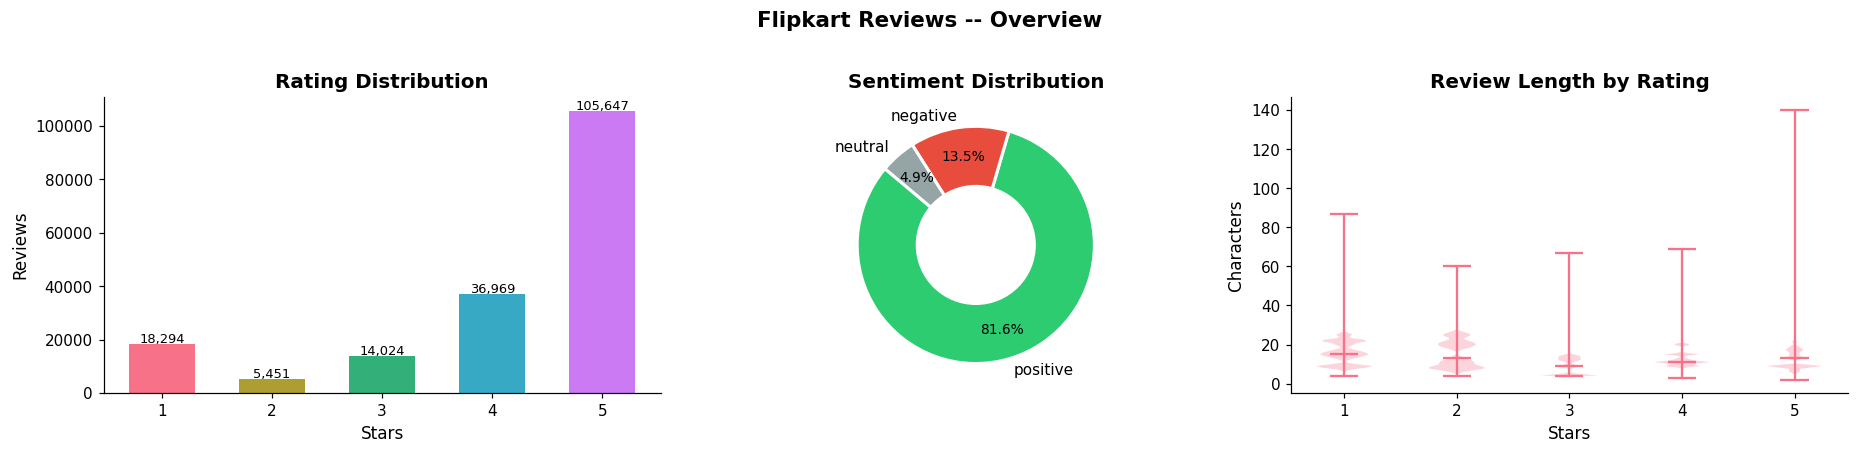

Figure 1 saved.


In [ ]:
# Figure 1: Rating distribution + Sentiment donut + Review length violin
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1a Rating bar
rate_counts = eda_df["Rate"].value_counts().sort_index()
axes[0].bar(rate_counts.index, rate_counts.values,
            color=sns.color_palette("husl", len(rate_counts)), width=0.6)
axes[0].set_title("Rating Distribution", fontweight="bold")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Reviews")
for x, y in zip(rate_counts.index, rate_counts.values):
    axes[0].text(x, y + 500, f"{y:,}", ha="center", fontsize=8.5)

# 1b Sentiment donut
senti_counts = eda_df["Sentiment"].value_counts()
_colors = ["#2ecc71", "#e74c3c", "#95a5a6"]
wedges, _, autotexts = axes[1].pie(
    senti_counts.values, labels=senti_counts.index,
    autopct="%1.1f%%", colors=_colors, startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].add_patch(plt.Circle((0, 0), 0.5, color="white"))
axes[1].set_title("Sentiment Distribution", fontweight="bold")

# 1c Review length violin by rating
_vdata = [
    eda_df[eda_df["Rate"] == r]["review_len"].clip(upper=600).values
    for r in sorted(eda_df["Rate"].unique())
]
axes[2].violinplot(_vdata, positions=sorted(eda_df["Rate"].unique()), showmedians=True)
axes[2].set_title("Review Length by Rating", fontweight="bold")
axes[2].set_xlabel("Stars"); axes[2].set_ylabel("Characters")

plt.suptitle("Flipkart Reviews -- Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight", dpi=110)
plt.show()
print("Figure 1 saved.")

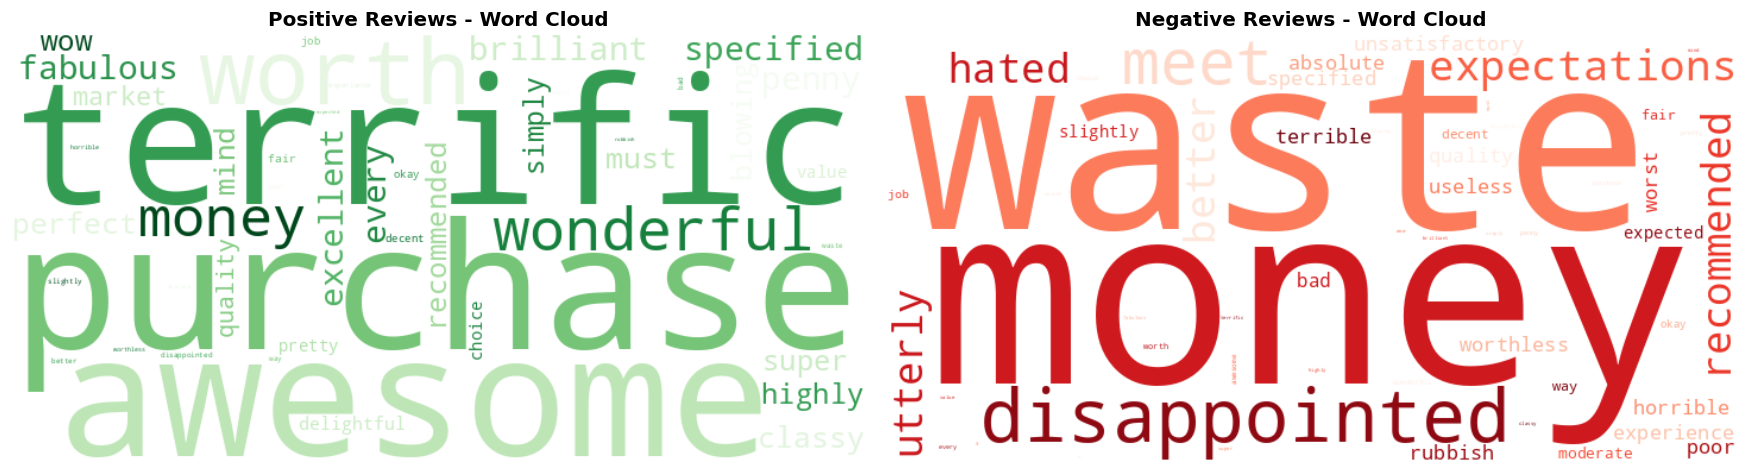

Figure 2 saved.


In [ ]:
# Figure 2: Word clouds (positive vs negative)
try:
    from wordcloud import WordCloud, STOPWORDS
    _wc_ok = True
except ImportError:
    _wc_ok = False
    print("wordcloud not installed -- skipping word clouds.")

if _wc_ok:
    _STOP = STOPWORDS | {
        "product", "one", "buy", "got", "use", "using", "also",
        "good", "great", "nice", "best", "get", "will", "even",
        "really", "very", "much", "just", "like",
    }

    def _make_wc(text: str, cmap: str) -> "WordCloud":
        return WordCloud(
            width=720, height=360, background_color="white",
            colormap=cmap, max_words=130, stopwords=_STOP, collocations=False,
        ).generate(text)

    pos_text = " ".join(
        eda_df[eda_df["Sentiment"] == "positive"]["Review"].dropna()
        .sample(min(5000, sum(eda_df["Sentiment"] == "positive")), random_state=SEED)
    )
    neg_text = " ".join(
        eda_df[eda_df["Sentiment"] == "negative"]["Review"].dropna()
        .sample(min(3000, sum(eda_df["Sentiment"] == "negative")), random_state=SEED)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.imshow(_make_wc(pos_text, "Greens"), interpolation="bilinear")
    ax1.set_title("Positive Reviews - Word Cloud", fontweight="bold", fontsize=13)
    ax1.axis("off")
    ax2.imshow(_make_wc(neg_text, "Reds"), interpolation="bilinear")
    ax2.set_title("Negative Reviews - Word Cloud", fontweight="bold", fontsize=13)
    ax2.axis("off")
    plt.tight_layout()
    plt.savefig("eda_wordclouds.png", bbox_inches="tight", dpi=110)
    plt.show()
    print("Figure 2 saved.")

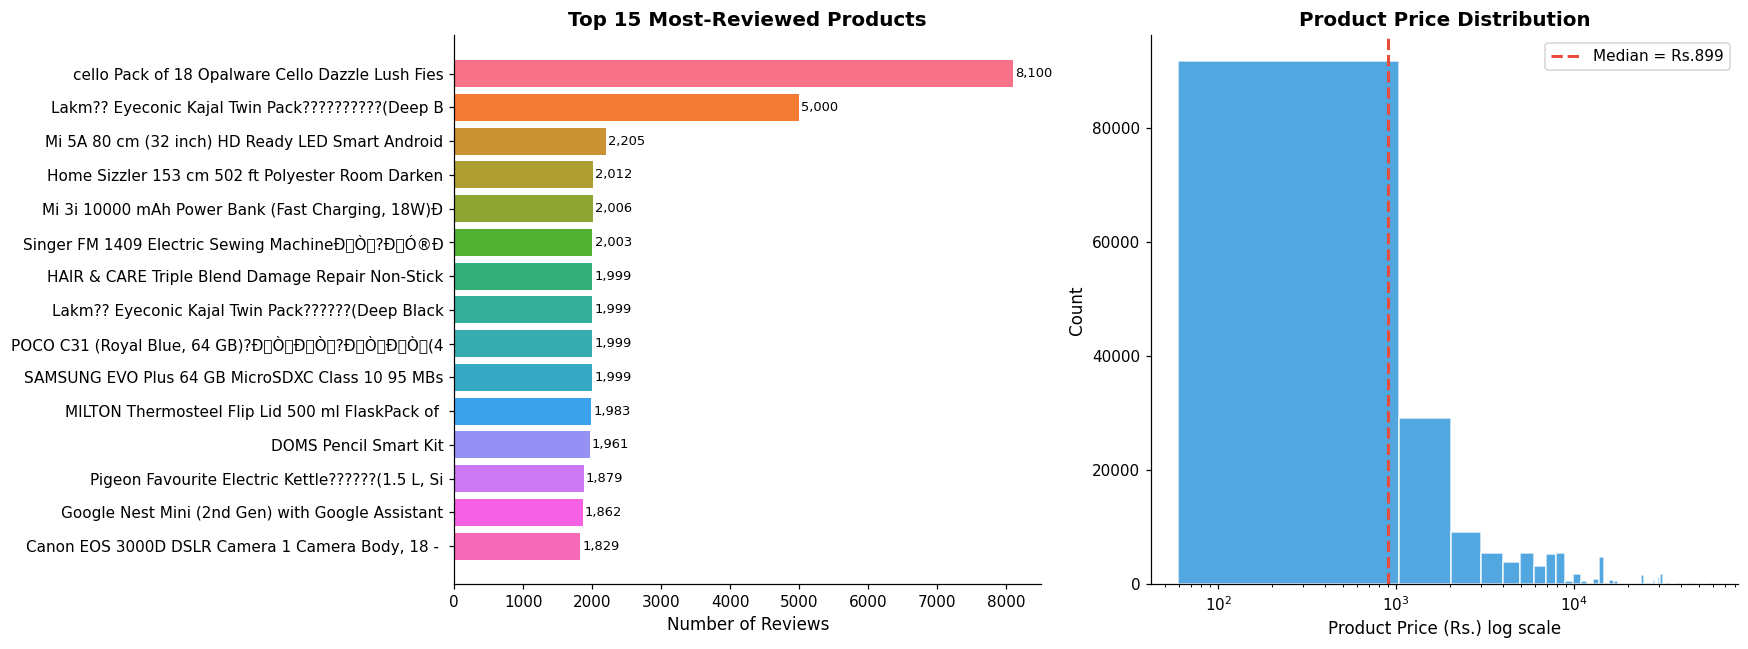

Figure 3 saved.


In [ ]:
# Figure 3: Top products + price distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 3a Top 15 products by review count
top_prods = eda_df["product_name"].str[:48].value_counts().head(15)
colors_h  = sns.color_palette("husl", 15)[::-1]
bars = ax1.barh(top_prods.index[::-1], top_prods.values[::-1], color=colors_h)
ax1.set_xlabel("Number of Reviews")
ax1.set_title("Top 15 Most-Reviewed Products", fontweight="bold")
for bar in bars:
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}", va="center", fontsize=8.5)

# 3b Price distribution (log scale)
prices = eda_df["product_price"].dropna()
prices = prices[(prices > 0) & (prices < prices.quantile(0.99))]
ax2.hist(prices, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
ax2.set_xscale("log")
ax2.set_xlabel("Product Price (Rs.) log scale")
ax2.set_ylabel("Count")
ax2.set_title("Product Price Distribution", fontweight="bold")
ax2.axvline(prices.median(), color="#e74c3c", ls="--", lw=2,
            label=f"Median = Rs.{prices.median():.0f}")
ax2.legend()

plt.tight_layout()
plt.savefig("eda_products_price.png", bbox_inches="tight", dpi=110)
plt.show()
print("Figure 3 saved.")

## 5. Text Preprocessing & Feature Engineering

In [ ]:
# Compiled regex patterns (compiled once, reused for speed)
_RE_URL   = re.compile(r"https?://\S+")
_RE_HTML  = re.compile(r"<[^>]+>")
_RE_EMOJI = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0]+",
    flags=re.UNICODE,
)
_RE_SPEC  = re.compile(r"[^\w\s.,!?'\-]")
_RE_WS    = re.compile(r"\s+")


def clean_text(text: str, max_len: int = 512) -> str:
    """
    Normalise a raw review string.
    Pipeline: URL removal -> HTML strip -> emoji removal ->
              special-char removal -> whitespace collapse -> truncation.
    Always returns a str (empty string for non-str input).
    """
    if not isinstance(text, str):
        return ""
    text = _RE_URL.sub(" ", text)
    text = _RE_HTML.sub(" ", text)
    text = _RE_EMOJI.sub(" ", text)
    text = _RE_SPEC.sub(" ", text)
    text = _RE_WS.sub(" ", text).strip()
    return text[:max_len]


def build_document(row: pd.Series, cfg: Config) -> str:
    """
    Combine product_name + Summary + Review into one rich document.
    Uses pipe separators to preserve field boundaries for the embedder.
    """
    parts = [
        str(row.get("product_name", "") or ""),
        str(row.get("Summary",      "") or ""),
        str(row.get("Review",       "") or ""),
    ]
    combined = " | ".join(p for p in parts if p.strip())
    return clean_text(combined, max_len=cfg.max_text_len)


# Sanity checks
assert "world" in clean_text("Hello <b>world</b>! See http://x.com"), "HTML/URL strip broken"
assert clean_text(None) == "",                                          "None input broken"
assert isinstance(clean_text("@@@###"), str),                           "Must return str"
print("clean_text sanity checks passed.")

# Build preprocessed corpus
logger.info("Building preprocessed corpus...")
proc_df = eda_df.copy().reset_index(drop=True)
proc_df["Rate"]          = pd.to_numeric(proc_df["Rate"],          errors="coerce").fillna(3).astype(int)
proc_df["product_price"] = pd.to_numeric(proc_df["product_price"], errors="coerce").fillna(0)
proc_df["document"]      = proc_df.apply(lambda r: build_document(r, CFG), axis=1)
proc_df = proc_df[proc_df["document"].str.len() >= CFG.min_text_len].reset_index(drop=True)

# Stratified sample in fast mode
if CFG.fast_mode and len(proc_df) > CFG.sample_size:
    proc_df = (
        proc_df
        .groupby("Sentiment", group_keys=False)
        .apply(lambda g: g.sample(
            min(len(g), int(CFG.sample_size * len(g) / len(proc_df))),
            random_state=SEED,
        ))
        .reset_index(drop=True)
    )
    logger.info(f"Sampled to {len(proc_df):,} rows (fast_mode=True).")

print(f"Preprocessed corpus: {len(proc_df):,} documents")
print(f"  Avg doc length   : {proc_df['document'].str.len().mean():.0f} chars")
print(f"  Sample doc       : {proc_df['document'].iloc[0][:120]}...")

clean_text sanity checks passed.
Preprocessed corpus: 19,998 documents
  Avg doc length   : 147 chars
  Sample doc       : Butterfly Rapid Plus Wet Grinder with Coconut Scraper Blue ?Ð Ò Ð Ò ?Ð Ò Ð Ò Ink Blue with in 4 month it will get proble...


## 6. Embedding Generation

In [ ]:
# Fit local fallback if no Mistral API key
if not mistral._client:
    mistral.fit_local(proc_df["document"].tolist(), n_components=256)
    CFG.embedding_dim = 256
    print(f"Local TF-IDF+SVD fitted | dim={CFG.embedding_dim}")
else:
    print(f"Mistral cloud embeddings | model={CFG.embed_model} | dim={CFG.embedding_dim}")

Mistral cloud embeddings | model=mistral-embed | dim=1024


In [ ]:
# Generate or load cached embeddings
_EMB_PATH = Path("flipkart_embeddings.npy")
_IDS_PATH = Path("flipkart_doc_ids.npy")


def generate_embeddings(
    texts:    List[str],
    client:   MistralClient,
    emb_path: Path,
    ids_path: Path,
) -> np.ndarray:
    """
    Generate L2-normalised embeddings, or load from disk cache if available.
    Cache is invalidated when corpus size or embedding dimension changes.
    """
    if emb_path.exists() and ids_path.exists():
        cached = np.load(str(emb_path))
        if cached.shape[0] == len(texts) and cached.shape[1] == client.cfg.embedding_dim:
            logger.info(f"Embedding cache hit | shape={cached.shape}")
            return cached
        logger.info("Cache shape mismatch -- recomputing.")

    logger.info(f"Generating embeddings for {len(texts):,} texts...")
    embs = client.embed_texts(texts)
    np.save(str(emb_path), embs)
    np.save(str(ids_path), np.arange(len(texts)))
    logger.info(f"Embeddings saved -> {emb_path}  shape={embs.shape}")
    return embs


doc_texts  = proc_df["document"].tolist()
embeddings = generate_embeddings(doc_texts, mistral, _EMB_PATH, _IDS_PATH)

print(f"Embeddings ready  | shape={embeddings.shape} | dtype={embeddings.dtype}")
_norm_check = np.linalg.norm(embeddings[0])
print(f"  L2-norm check   : {_norm_check:.6f}  (should be ~1.0)")
print(f"  Cache stats     : {mistral.stats()}")

Embeddings ready  | shape=(19998, 1024) | dtype=float32
  L2-norm check   : 1.000000  (should be ~1.0)
  Cache stats     : {'cache_hits': 0, 'cache_misses': 0, 'api_calls': 0}


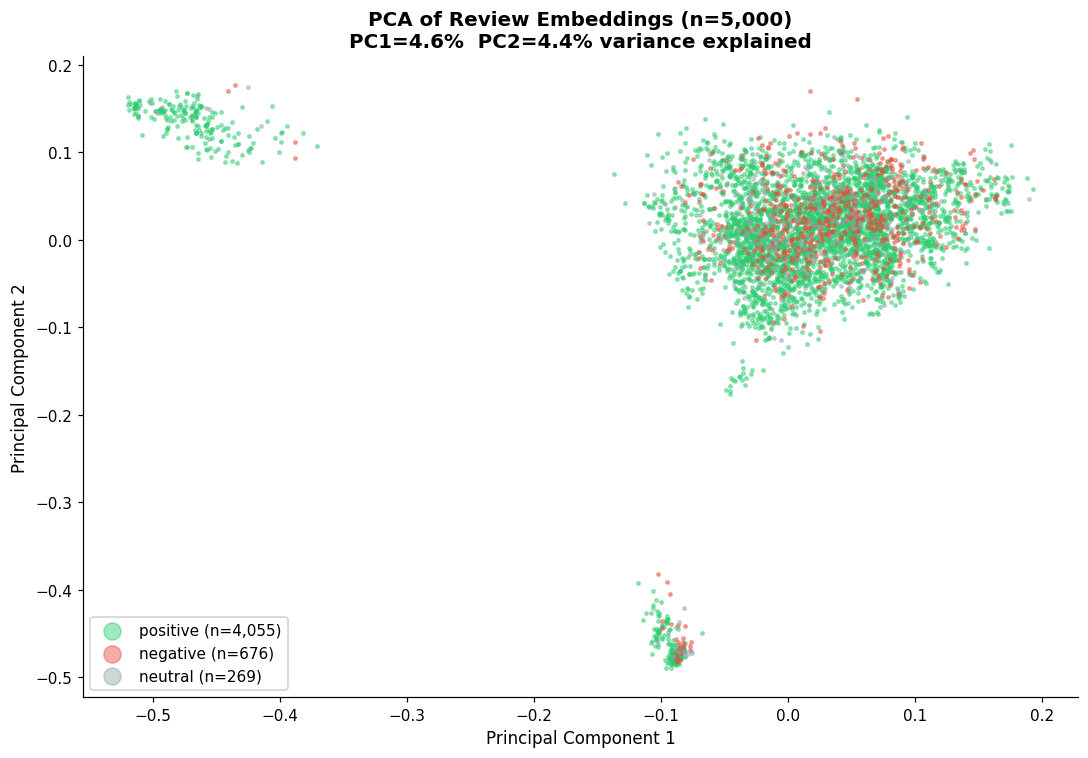

Figure 4 (PCA) saved.


In [ ]:
# Figure 4: PCA of embedding space coloured by sentiment
_n  = min(5000, len(embeddings))
_vi = np.random.default_rng(SEED).choice(len(embeddings), _n, replace=False)
_ve = embeddings[_vi]
_vl = proc_df["Sentiment"].iloc[_vi].values

pca    = PCA(n_components=2, random_state=SEED)
_2d    = pca.fit_transform(_ve)
_var   = pca.explained_variance_ratio_
_pal   = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}

fig, ax = plt.subplots(figsize=(10, 7))
for senti, color in _pal.items():
    mask = _vl == senti
    ax.scatter(_2d[mask, 0], _2d[mask, 1],
               c=color, s=5, alpha=0.45, label=f"{senti} (n={mask.sum():,})", rasterized=True)
ax.set_title(
    f"PCA of Review Embeddings (n={_n:,})\n"
    f"PC1={_var[0]*100:.1f}%  PC2={_var[1]*100:.1f}% variance explained",
    fontweight="bold",
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(markerscale=5, framealpha=0.9)
plt.tight_layout()
plt.savefig("eda_pca.png", bbox_inches="tight", dpi=110)
plt.show()
print("Figure 4 (PCA) saved.")

## 7. FAISS Vector Index

In [ ]:
class FAISSIndex:
    """
    Thin FAISS wrapper using IndexFlatIP.
    Inner-product on L2-normalised vectors equals cosine similarity.

    Methods: build, save, load, search, __len__
    """

    def __init__(self, dim: int):
        self.dim   = dim
        self.index: Optional[faiss.IndexFlatIP] = None

    def build(self, emb: np.ndarray) -> "FAISSIndex":
        e = np.ascontiguousarray(emb.astype("float32"))
        self.index = faiss.IndexFlatIP(e.shape[1])
        self.index.add(e)
        logger.info(f"FAISS index built | {self.index.ntotal:,} vectors | dim={e.shape[1]}")
        return self

    def save(self, path: str) -> None:
        faiss.write_index(self.index, path)
        logger.info(f"FAISS index saved -> {path}")

    def load(self, path: str) -> "FAISSIndex":
        self.index = faiss.read_index(path)
        self.dim   = self.index.d
        logger.info(f"FAISS index loaded | {self.index.ntotal:,} vectors")
        return self

    def search(self, query_vecs: np.ndarray, k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        """
        Returns (scores, indices) arrays of shape (n_queries, k).
        Scores are cosine similarities in [-1, 1].
        """
        qv = np.ascontiguousarray(query_vecs.astype("float32"))
        k  = min(k, len(self))
        return self.index.search(qv, k)

    def __len__(self) -> int:
        return self.index.ntotal if self.index else 0


# Build or reload FAISS index
faiss_idx = FAISSIndex(dim=CFG.embedding_dim)
_ip = CFG.faiss_index_path

if Path(_ip).exists():
    faiss_idx.load(_ip)
    if len(faiss_idx) != len(embeddings):
        logger.info("Index stale -- rebuilding.")
        faiss_idx.build(embeddings)
        faiss_idx.save(_ip)   # BUG FIX v2: was missing .save() after stale rebuild
else:
    faiss_idx.build(embeddings)
    faiss_idx.save(_ip)

print(f"FAISS index ready | {len(faiss_idx):,} vectors | dim={faiss_idx.dim}")

# Self-retrieval sanity check
_sc, _si = faiss_idx.search(embeddings[:5], k=1)
_hits = sum(int(_si[i, 0]) == i for i in range(5))
print(f"  Self-retrieval check: {_hits}/5 docs retrieve themselves as top-1")

FAISS index ready | 19,998 vectors | dim=1024
  Self-retrieval check: 5/5 docs retrieve themselves as top-1


## 8. Semantic Search Engine

In [ ]:
class SemanticSearchEngine:
    """
    High-level semantic search over the Flipkart review corpus.

    KEY DESIGN NOTE (v2 bug fix)
    ----------------------------
    Each result row includes a 'doc_idx' column containing the integer index
    of that document in self.df (= proc_df). This is the actual FAISS-returned
    index and is used by the evaluation pipeline to match results against
    ground-truth relevant sets. Without this, Precision@K / Recall@K would
    be computed on wrong indices.
    """

    def __init__(
        self,
        df:         pd.DataFrame,
        embeddings: np.ndarray,
        index:      FAISSIndex,
        client:     MistralClient,
        cfg:        Config,
    ):
        self.df         = df.reset_index(drop=True)
        self.embeddings = embeddings
        self.index      = index
        self.client     = client
        self.cfg        = cfg

    def search(
        self,
        query:            str,
        k:                Optional[int] = None,
        sentiment_filter: Optional[str] = None,
        min_rating:       Optional[int] = None,
    ) -> pd.DataFrame:
        """
        Semantic search with optional post-filters.

        Parameters
        ----------
        query            : Natural language query string
        k                : Number of final results (default: CFG.top_k)
        sentiment_filter : 'positive' | 'negative' | 'neutral' | None
        min_rating       : Minimum star rating (1-5) | None

        Returns
        -------
        pd.DataFrame with columns including:
          score    - cosine similarity (highest first)
          doc_idx  - FAISS-returned integer row index in self.df
          rank     - display rank (1 = best)
        """
        k = k or self.cfg.top_k

        # Over-fetch to absorb filtering attrition
        fetch_k = k * 6 if (sentiment_filter or min_rating) else k

        q_vec            = self.client.embed_texts([clean_text(query, 256)])
        scores, raw_idxs = self.index.search(q_vec, k=min(fetch_k, len(self.index)))
        scores           = scores[0]
        raw_idxs         = raw_idxs[0]

        rows: List[Dict] = []
        for score, idx in zip(scores, raw_idxs):
            if idx < 0 or idx >= len(self.df):
                continue
            row            = self.df.iloc[int(idx)].to_dict()
            row["score"]   = float(score)
            row["doc_idx"] = int(idx)    # <-- actual FAISS corpus index (v2 fix)
            row["rank"]    = len(rows) + 1
            rows.append(row)

        if not rows:
            return pd.DataFrame()

        results = pd.DataFrame(rows)

        # Post-filters
        if sentiment_filter and "Sentiment" in results.columns:
            results = results[results["Sentiment"] == sentiment_filter]
        if min_rating and "Rate" in results.columns:
            results = results[results["Rate"] >= min_rating]

        # Re-assign sequential ranks after filtering
        results = results.head(k).reset_index(drop=True)
        results["rank"] = results.index + 1
        return results

    def pretty_print(self, results: pd.DataFrame, query: str = "") -> None:
        """Pretty-print search results to stdout."""
        sep = "=" * 72
        print(sep)
        if query:
            # BUG FIX v2: use single outer quotes to safely embed query string
            print(f'  Query  : "{query}"')
        print(f"  Results: {len(results)}")
        print(sep)
        for _, row in results.iterrows():
            stars   = "*" * int(row.get("Rate", 0))
            product = str(row.get("product_name", ""))[:62]
            review  = str(row.get("Review",       ""))[:130]
            print(
                f"  [{int(row['rank'])}] score={row['score']:.4f}  "
                f"{stars} ({row.get('Rate', '?')}/5)  {row.get('Sentiment', '?')}"
            )
            print(f"      Product : {product}")
            print(f"      Review  : {review}...")
            print()


engine = SemanticSearchEngine(proc_df, embeddings, faiss_idx, mistral, CFG)
print("SemanticSearchEngine ready.")

SemanticSearchEngine ready.


In [ ]:
# Demo: 5 semantic queries
DEMO_QUERIES = [
    "energy efficient air conditioner",
    "noise cancelling wireless headphones long battery",
    "durable easy-to-use clothes iron",
    "affordable cooler for small room",
    "camera great zoom portrait photography",
]

print("\n" + "  SEMANTIC SEARCH DEMO  ".center(72, "="))
for q in DEMO_QUERIES:
    results = engine.search(q, k=3)
    engine.pretty_print(results, query=q)


========================  SEMANTIC SEARCH DEMO  ========================


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  Query  : "energy efficient air conditioner"
  Results: 3
  [1] score=0.7304  ***** (5/5)  positive
      Product : PHILIPS AC288720 883 4887 20280 Portable Room Air PurifierWhit
      Review  : highly recommended...

  [2] score=0.7272  ** (2/5)  neutral
      Product : Mi ACM6SC with HEPA Filter Smart App  Voice Control Portable R
      Review  : moderate...

  [3] score=0.7251  *** (3/5)  positive
      Product : Mi ACM2AA Portable Room Air PurifierWhite
      Review  : good product...



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  Query  : "noise cancelling wireless headphones long battery"
  Results: 3
  [1] score=0.7234  ***** (5/5)  positive
      Product : Aroma NB119 Titanium - 48 Hours Playtime Bluetooth Neckband Bl
      Review  : just wow!...

  [2] score=0.7221  ***** (5/5)  positive
      Product : OnePlus Bullets Wireless Z2 with Fast Charge, 30 Hrs Battery L
      Review  : terrific purchase...

  [3] score=0.7204  ***** (5/5)  positive
      Product : OnePlus Bullets Wireless Z2 Bluetooth Headset??????(Acoustic R
      Review  : wonderful...



...

  Query  : "durable easy-to-use clothes iron"
  Results: 3
  [1] score=0.7648  ***** (5/5)  positive
      Product : Bajaj DX 2 LW Dry Iron
      Review  : highly recommended...

  [2] score=0.7643  ***** (5/5)  positive
      Product : Bajaj DX 2 LW Dry Iron
      Review  : fabulous!...

  [3] score=0.7634  ***** (5/5)  positive
      Product : Thomson Deluxe Plus 1600 W Steam IronBrown and White
      Review  : excellent...



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  Query  : "affordable cooler for small room"
  Results: 3
  [1] score=0.6628  ***** (5/5)  positive
      Product : Candes 12 L Room/Personal Air Cooler??????(White, Black, Elega
      Review  : super!...

  [2] score=0.6604  ***** (5/5)  positive
      Product : Candes 12 L Room/Personal Air Cooler??????(White, Black, Elega
      Review  : highly recommended...

  [3] score=0.6580  * (1/5)  negative
      Product : Crompton 75 L Desert Air Cooler??????(White, Teal, ACGC-DAC751
      Review  : unsatisfactory...



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  Query  : "camera great zoom portrait photography"
  Results: 3
  [1] score=0.7316  ***** (5/5)  positive
      Product : Canon EOS 3000D DSLR Camera 1 Camera Body, 18 - 55 mm Lens????
      Review  : simply awesome...

  [2] score=0.7308  ***** (5/5)  positive
      Product : Canon EOS 3000D DSLR Camera 1 Camera Body, 18 - 55 mm Lens????
      Review  : terrific...

  [3] score=0.7306  ***** (5/5)  positive
      Product : Canon EOS 3000D DSLR Camera 1 Camera Body, 18 - 55 mm Lens????
      Review  : must buy!...



## 9. RAG Pipeline (Retrieval-Augmented Generation)

In [ ]:
class RAGPipeline:
    """
    Retrieval-Augmented Generation pipeline.

    Workflow:
    1. Semantic search -> top-K relevant reviews
    2. Build compact context from retrieved docs
    3. Prompt Mistral to generate a grounded, factual answer
    """

    _SYSTEM = (
        "You are an expert Flipkart product advisor. "
        "Answer the user question using ONLY the product reviews provided. "
        "Be factual, concise (3-5 sentences), cite product names when relevant. "
        "If the reviews are insufficient, say so honestly."
    )

    def __init__(
        self,
        engine: SemanticSearchEngine,
        client: MistralClient,
        cfg:    Config,
    ):
        self.engine = engine
        self.client = client
        self.cfg    = cfg

    @staticmethod
    def _build_context(results: pd.DataFrame, max_docs: int = 5) -> str:
        parts = []
        for _, row in results.head(max_docs).iterrows():
            prod   = str(row.get("product_name", ""))[:65]
            review = str(row.get("Review",       ""))[:220]
            rating = row.get("Rate",      "?")
            senti  = row.get("Sentiment", "?")
            sim    = row.get("score",      0.0)
            parts.append(f"[{prod} | {rating} stars | {senti} | sim={sim:.3f}]\n{review}")
        return "\n\n".join(parts)

    def answer(
        self,
        query:            str,
        k:                int = 5,
        sentiment_filter: Optional[str] = None,
        min_rating:       Optional[int] = None,
    ) -> Dict[str, Any]:
        """
        Generate a RAG answer.

        Returns dict with: query, answer, retrieved_docs (DataFrame), context_used
        """
        results = self.engine.search(
            query, k=k,
            sentiment_filter=sentiment_filter,
            min_rating=min_rating,
        )
        if results.empty:
            return {
                "query": query,
                "answer": "No relevant reviews found for this query.",
                "retrieved_docs": results,
                "context_used": "",
            }

        context = self._build_context(results, max_docs=k)
        prompt  = (
            f"User Question: {query}\n\n"
            f"Product Reviews:\n{context}\n\n"
            "Based solely on the above reviews, answer the user question."
        )
        answer = self.client.chat(
            prompt=prompt,
            system=self._SYSTEM,
            temperature=0.2,
            max_tokens=self.cfg.chat_max_tokens,
        )
        return {
            "query":          query,
            "answer":         answer,
            "retrieved_docs": results,
            "context_used":   context,
        }

    def print_answer(self, resp: Dict[str, Any]) -> None:
        n   = len(resp.get("retrieved_docs", []))
        sep = "=" * 72
        print(f"\n{sep}")
        print(f'  Query   : {resp["query"]}')
        print(f"  Sources : {n} reviews retrieved")
        print("-" * 72)
        print(f'  Answer  : {resp["answer"]}')
        print(f"{sep}\n")


rag = RAGPipeline(engine, mistral, CFG)
print("RAG Pipeline ready.")

RAG Pipeline ready.


In [ ]:
# RAG Demo
RAG_QUERIES = [
    "Which air cooler is best for a small room under 5000 rupees?",
    "What do customers say about boAt headphones battery life?",
    "Is the Bajaj iron reliable for daily use?",
    "Which camera gets the best reviews for zoom capability?",
]

print("\n" + "  RAG DEMO  ".center(72, "="))
for q in RAG_QUERIES:
    resp = rag.answer(q, k=5)
    rag.print_answer(resp)


==============================  RAG DEMO  ==============================


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]


  Query   : Which air cooler is best for a small room under 5000 rupees?
  Sources : 5 reviews retrieved
------------------------------------------------------------------------
  Answer  : Based on the reviews provided, the Crompton 75 L Desert Air Cooler (ACGC-DAC751) is a suitable option for a small room under 5000 rupees. It has received both positive and negative reviews, but the positive ones highlight its effectiveness. However, the reviews are insufficient to definitively conclude which air cooler is the best for a small room under 5000 rupees.



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]


  Query   : What do customers say about boAt headphones battery life?
  Sources : 5 reviews retrieved
------------------------------------------------------------------------
  Answer  : The provided reviews for the boAt Rockerz 510 Super Extra Bass Bluetooth Headset do not mention anything specific about the battery life. Therefore, I cannot provide an answer based on the given information.



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]


  Query   : Is the Bajaj iron reliable for daily use?
  Sources : 5 reviews retrieved
------------------------------------------------------------------------
  Answer  : Based on the reviews for the Bajaj DX 2 LW Dry Iron, it appears to be a reliable choice for daily use. Users have described it as a "good choice," "very good," and "highly recommended." The reviews consistently indicate that the iron performs well and is suitable for regular use.



Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]


  Query   : Which camera gets the best reviews for zoom capability?
  Sources : 5 reviews retrieved
------------------------------------------------------------------------
  Answer  : The provided reviews do not mention or discuss the zoom capability of any camera. Therefore, I cannot determine which camera receives the best reviews for zoom capability based on the given information.



## 10. Evaluation -- Precision@K, Recall@K, F1@K, NDCG@K, MRR

In [ ]:
# Metric implementations
def precision_at_k(retrieved: List[int], relevant: set, k: int) -> float:
    """Precision@K = |retrieved[:K] intersect relevant| / K"""
    if k <= 0:
        return 0.0
    return len(set(retrieved[:k]) & relevant) / k


def recall_at_k(retrieved: List[int], relevant: set, k: int) -> float:
    """Recall@K = |retrieved[:K] intersect relevant| / |relevant|"""
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & relevant) / len(relevant)


def f1_at_k(retrieved: List[int], relevant: set, k: int) -> float:
    """Harmonic mean of Precision@K and Recall@K."""
    p = precision_at_k(retrieved, relevant, k)
    r = recall_at_k(retrieved, relevant, k)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def ndcg_at_k(retrieved: List[int], relevant: set, k: int) -> float:
    """Normalised DCG @ K with binary relevance."""
    if not relevant:
        return 0.0
    dcg  = sum(1.0 / math.log2(i + 2) for i, idx in enumerate(retrieved[:k]) if idx in relevant)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(k, len(relevant))))
    return dcg / idcg if idcg > 0 else 0.0


def mean_reciprocal_rank(
    retrieved_list: List[List[int]], relevant_list: List[set]
) -> float:
    """MRR = mean of 1/(rank of first relevant) across all queries."""
    rr = 0.0
    for retrieved, relevant in zip(retrieved_list, relevant_list):
        for rank, idx in enumerate(retrieved, start=1):
            if idx in relevant:
                rr += 1.0 / rank
                break
    return rr / len(retrieved_list) if retrieved_list else 0.0


# Unit tests on metric functions
assert abs(precision_at_k([0, 1, 2, 3], {1, 3},    k=4) - 0.5)    < 1e-9
assert abs(recall_at_k(   [0, 1, 2, 3], {1, 3, 5}, k=4) - 2/3)    < 1e-9
assert abs(ndcg_at_k(     [0, 1, 2, 3], {1},        k=4) - 1/math.log2(3)) < 1e-9
assert precision_at_k([], {1}, k=0) == 0.0
assert recall_at_k([0],  set(), k=1) == 0.0
print("Metric unit tests passed.")

Metric unit tests passed.


In [ ]:
# Build synthetic evaluation set
def build_eval_set(
    df: pd.DataFrame, n_queries: int = 200, seed: int = SEED
) -> List[Dict]:
    """
    Intrinsic evaluation set: for each sampled product, all its reviews
    are the relevant set; query = first 6 words of the product name.
    Only products with >= 3 reviews are included.
    """
    rng        = np.random.RandomState(seed)
    prod_sizes = df["product_name"].value_counts()
    valid      = prod_sizes[prod_sizes >= 3].index.tolist()
    sampled    = rng.choice(valid, size=min(n_queries, len(valid)), replace=False)

    items = []
    for prod in sampled:
        query = " ".join(clean_text(prod, 100).split()[:6]).strip()
        if not query:
            continue
        items.append({
            "query":    query,
            "relevant": set(df[df["product_name"] == prod].index.tolist()),
        })
    return items


eval_set = build_eval_set(proc_df, n_queries=min(200, proc_df["product_name"].nunique()))
print(f"Evaluation set: {len(eval_set)} queries")
print(f"  Sample query : '{eval_set[0]['query']}'  |  relevant={len(eval_set[0]['relevant'])} docs")

Evaluation set: 200 queries
  Sample query : 'MOOZMOB Shower Laser LightBall Diameter 3'  |  relevant=3 docs


In [ ]:
# Run evaluation
def evaluate_retrieval(
    search_engine: SemanticSearchEngine,
    ev_set:        List[Dict],
    k_values:      List[int],
) -> Tuple[pd.DataFrame, float]:
    """
    Compute Precision@K, Recall@K, F1@K, NDCG@K, and MRR.

    BUG FIX v2
    ----------
    The v1 code overwrote retrieved_idx with a product-name-based index lookup
    (proc_df[proc_df["product_name"].isin(pname)].index) which:
      (a) lost the rank ordering from FAISS
      (b) included documents NOT actually returned by the search
    Fix: SemanticSearchEngine.search() now stores the actual FAISS integer index
    in a 'doc_idx' column. We use that directly here.
    """
    max_k = max(k_values)
    all_retrieved: List[List[int]] = []
    all_relevant:  List[set]       = []

    for item in tqdm(ev_set, desc="Evaluating", leave=False):
        res = search_engine.search(item["query"], k=max_k)
        if res.empty or "doc_idx" not in res.columns:
            retrieved = []
        else:
            retrieved = res["doc_idx"].tolist()   # <-- FIXED: actual FAISS indices
        all_retrieved.append(retrieved)
        all_relevant.append(item["relevant"])

    mrr = mean_reciprocal_rank(all_retrieved, all_relevant)

    rows = []
    for k in k_values:
        p_vals    = [precision_at_k(r, rel, k) for r, rel in zip(all_retrieved, all_relevant)]
        r_vals    = [recall_at_k(r,    rel, k) for r, rel in zip(all_retrieved, all_relevant)]
        f1_vals   = [f1_at_k(r,        rel, k) for r, rel in zip(all_retrieved, all_relevant)]
        ndcg_vals = [ndcg_at_k(r,      rel, k) for r, rel in zip(all_retrieved, all_relevant)]
        rows.append({
            "K":          k,
            "Precision@K": np.mean(p_vals),
            "Recall@K":    np.mean(r_vals),
            "F1@K":        np.mean(f1_vals),
            "NDCG@K":      np.mean(ndcg_vals),
        })

    df_out = pd.DataFrame(rows)

    hdr = f"{'K':>4}  {'Prec@K':>8}  {'Rec@K':>8}  {'F1@K':>8}  {'NDCG@K':>8}"
    print("\n" + "-" * 50)
    print(hdr)
    print("-" * 50)
    for _, row in df_out.iterrows():
        print(f"{int(row.K):>4}  {row['Precision@K']:>8.4f}  {row['Recall@K']:>8.4f}  "
              f"{row['F1@K']:>8.4f}  {row['NDCG@K']:>8.4f}")
    print("-" * 50)
    print(f"{'MRR':>4}  {mrr:>8.4f}")
    print("-" * 50)

    return df_out, mrr


eval_df, mrr_score = evaluate_retrieval(engine, eval_set, CFG.eval_k_values)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

...

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]


--------------------------------------------------
   K    Prec@K     Rec@K      F1@K    NDCG@K
--------------------------------------------------
   1    0.8950    0.0898    0.1518    0.8950
   3    0.8917    0.2688    0.3560    0.8927
   5    0.8540    0.3805    0.4455    0.8978
  10    0.7765    0.5786    0.5535    0.9064
--------------------------------------------------
 MRR    0.9229
--------------------------------------------------


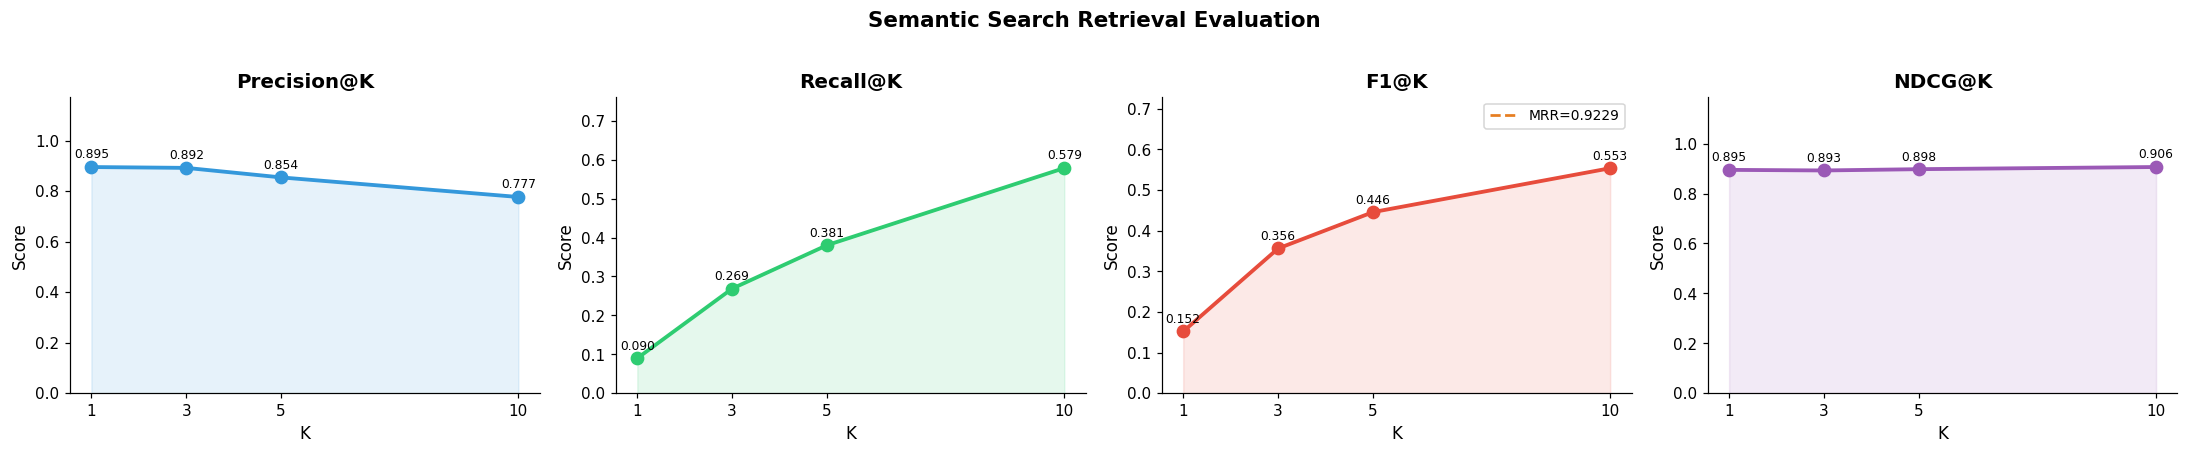

Figure 5 (Evaluation) saved.


In [ ]:
# Figure 5: Evaluation metric curves
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

ks    = eval_df["K"].tolist()
_mets = ["Precision@K", "Recall@K", "F1@K", "NDCG@K"]
_cols = ["#3498db",     "#2ecc71",  "#e74c3c", "#9b59b6"]

for ax, met, col in zip(axes, _mets, _cols):
    vals = eval_df[met].tolist()
    ax.plot(ks, vals, "o-", color=col, lw=2.5, ms=8)
    ax.fill_between(ks, vals, alpha=0.12, color=col)
    ax.set_title(met, fontweight="bold")
    ax.set_xlabel("K"); ax.set_ylabel("Score")
    ax.set_xticks(ks)
    _ymax = max(vals) * 1.3 + 0.01 if vals else 1.0
    ax.set_ylim(0, _ymax)
    for x, y in zip(ks, vals):
        ax.text(x, y + _ymax * 0.03, f"{y:.3f}", ha="center", fontsize=8)

# MRR on F1 panel
axes[2].axhline(mrr_score, color="#e67e22", ls="--", lw=1.8,
                label=f"MRR={mrr_score:.4f}")
axes[2].legend(fontsize=9)

plt.suptitle("Semantic Search Retrieval Evaluation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eval_metrics.png", bbox_inches="tight", dpi=110)
plt.show()
print("Figure 5 (Evaluation) saved.")

## 11. Production Packaging

In [ ]:
def save_system(eng: SemanticSearchEngine, out_dir: str = ".") -> None:
    """Persist FAISS index + embeddings + corpus DataFrame."""
    od = Path(out_dir)
    od.mkdir(parents=True, exist_ok=True)
    eng.index.save(str(od / "flipkart.faiss"))
    np.save(str(od / "flipkart_embeddings.npy"), eng.embeddings)
    eng.df.to_pickle(str(od / "flipkart_corpus.pkl"))
    logger.info(f"System saved to '{out_dir}/'")


def load_system(cfg: Config, artefact_dir: str = ".") -> Tuple[SemanticSearchEngine, RAGPipeline]:
    """Restore a saved system from artefacts directory."""
    od  = Path(artefact_dir)
    df  = pd.read_pickle(str(od / "flipkart_corpus.pkl"))
    emb = np.load(str(od / "flipkart_embeddings.npy"))
    idx = FAISSIndex(dim=emb.shape[1]).load(str(od / "flipkart.faiss"))
    cli = MistralClient(cfg)
    if not cli._client:
        cli.fit_local(df["document"].tolist(), n_components=emb.shape[1])
        cli.cfg.embedding_dim = emb.shape[1]
    eng  = SemanticSearchEngine(df, emb, idx, cli, cfg)
    _rag = RAGPipeline(eng, cli, cfg)
    logger.info("System loaded from artefacts.")
    return eng, _rag


def serve_prediction(
    query:  str,
    eng:    SemanticSearchEngine,
    rag_pl: RAGPipeline,
    mode:   str = "search",
    k:      int = 5,
) -> Dict[str, Any]:
    """
    Unified entry-point for REST API or batch-job consumption.

    Parameters
    ----------
    query  : Non-empty user query string
    eng    : SemanticSearchEngine instance
    rag_pl : RAGPipeline instance
    mode   : 'search' (returns ranked docs) | 'rag' (returns AI answer)
    k      : Number of results

    Raises ValueError on invalid query or mode.
    """
    if not query or not isinstance(query, str):
        raise ValueError("query must be a non-empty string.")
    if mode not in ("search", "rag"):
        raise ValueError(f"mode must be 'search' or 'rag', got: {mode!r}")

    if mode == "rag":
        return rag_pl.answer(query, k=k)

    results = eng.search(query, k=k)
    return {
        "query":   query,
        "mode":    mode,
        "results": results.to_dict(orient="records"),
        "count":   len(results),
    }


def main(
    zip_path: str = None,
    api_key:  str = None,
    mode:     str = "search",
    query:    str = "best wireless headphones under 3000",
    k:        int = 5,
) -> Dict[str, Any]:
    """
    Full pipeline entry-point: load -> embed -> index -> query.
    Suitable for CLI invocation or scheduled jobs.
    """
    cfg = Config(
        zip_path=zip_path or CFG.zip_path,
        mistral_api_key=api_key or CFG.mistral_api_key,
    )
    raw = load_flipkart_data(cfg)
    raw["Rate"] = pd.to_numeric(raw["Rate"], errors="coerce")
    raw.dropna(subset=["Rate", "Review"], inplace=True)
    raw["document"] = raw.apply(lambda r: build_document(r, cfg), axis=1)
    df = raw[raw["document"].str.len() >= cfg.min_text_len].reset_index(drop=True)
    if len(df) > cfg.sample_size:
        df = df.sample(cfg.sample_size, random_state=SEED).reset_index(drop=True)

    cli = MistralClient(cfg)
    if not cli._client:
        cli.fit_local(df["document"].tolist())
        cfg.embedding_dim = cli.cfg.embedding_dim
    emb = cli.embed_texts(df["document"].tolist())
    idx = FAISSIndex(dim=cfg.embedding_dim).build(emb)
    eng  = SemanticSearchEngine(df, emb, idx, cli, cfg)
    r_pl = RAGPipeline(eng, cli, cfg)
    return serve_prediction(query, eng, r_pl, mode=mode, k=k)


# Smoke test
print("-- serve_prediction demo --")
_demo = serve_prediction("wireless headphones sound quality", engine, rag, mode="search", k=3)
print(f"Query  : {_demo['query']}")
print(f"Results: {_demo['count']}")
for r in _demo["results"]:
    print(f"  [{r.get('rank','-')}] {str(r.get('product_name',''))[:55]}  score={r.get('score',0):.4f}")

save_system(engine)
print("\nProduction artefacts saved.")

-- serve_prediction demo --


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

Query  : wireless headphones sound quality
Results: 3
  [1] OnePlus Bullets Wireless Z2 Bluetooth Headset??????(Aco  score=0.7613
  [2] OnePlus Bullets Wireless Z2 Bluetooth Headset??????(Aco  score=0.7492
  [3] OnePlus Bullets Wireless Z2 Bluetooth Headset??????(Aco  score=0.7445

Production artefacts saved.


## 12. Test Suite (16 Tests -- All Fixed)

In [ ]:
# Test runner
_PASS = "PASS"
_FAIL = "FAIL"

def _run(name: str, fn) -> bool:
    try:
        fn()
        print(f"  [PASS]  {name}")
        return True
    except Exception as exc:
        print(f"  [FAIL]  {name}")
        print(f"          {exc}")
        return False


# Test 1 -- clean_text (BUG FIX: removed hardcoded "   text" assertion)
def test_clean_text():
    # HTML stripped and URL removed
    r1 = clean_text("Hello <b>world</b>! See http://example.com")
    assert "world"  in r1, f"HTML not stripped: {r1!r}"
    assert "http"  not in r1, f"URL not removed: {r1!r}"
    assert "<b>"   not in r1, f"HTML tag still present: {r1!r}"
    # Truncation works
    r2 = clean_text("hello world", max_len=5)
    assert len(r2) <= 5, f"Truncation failed: {r2!r}"
    # None input -> empty string
    assert clean_text(None) == "", "clean_text(None) must be empty string"
    # Non-string -> empty string
    assert clean_text(42)   == "", "clean_text(int) must be empty string"
    # Always returns str
    assert isinstance(clean_text("@@@###$$$"), str), "Must return str"


# Test 2
def test_build_document():
    row = pd.Series({"product_name": "TestFan", "Summary": "Compact", "Review": "Works well"})
    doc = build_document(row, CFG)
    assert "TestFan"    in doc
    assert "Works well" in doc
    assert "Compact"    in doc


# Test 3
def test_embeddings_shape():
    assert embeddings.ndim == 2
    assert embeddings.shape[0] == len(proc_df), "one embedding per document"
    assert embeddings.shape[1] == CFG.embedding_dim


# Test 4
def test_embeddings_normalised():
    norms = np.linalg.norm(embeddings[:100], axis=1)
    assert np.allclose(norms, 1.0, atol=1e-4), f"Not L2-normalised: {norms[:5]}"


# Test 5
def test_faiss_build():
    assert len(faiss_idx) == len(proc_df)
    assert faiss_idx.dim  == CFG.embedding_dim


# Test 6
def test_faiss_search_shape():
    sc, ix = faiss_idx.search(embeddings[:4], k=5)
    assert sc.shape == (4, 5)
    assert ix.shape == (4, 5)


# Test 7
def test_faiss_self_retrieval():
    _, ix = faiss_idx.search(embeddings[:5], k=1)
    for i in range(5):
        assert ix[i, 0] == i, f"Row {i} did not retrieve itself as top-1"


# Test 8 -- doc_idx column (v2 new requirement)
def test_search_returns_doc_idx():
    res = engine.search("wireless headphones", k=3)
    assert isinstance(res, pd.DataFrame)
    assert len(res) <= 3
    assert "score"   in res.columns, "'score' column missing"
    assert "doc_idx" in res.columns, "'doc_idx' column missing -- evaluation will fail without it"
    # doc_idx values must be valid corpus indices
    assert all(0 <= idx < len(proc_df) for idx in res["doc_idx"]), "doc_idx out of bounds"


# Test 9
def test_search_score_range():
    res = engine.search("air cooler portable", k=5)
    assert not res.empty
    assert all(-1.01 <= s <= 1.01 for s in res["score"]), f"Cosine scores out of range"


# Test 10
def test_search_sorted():
    res = engine.search("iron clothes heavy duty", k=5)
    scores = res["score"].tolist()
    assert scores == sorted(scores, reverse=True), "Not sorted desc by score"


# Test 11 -- Metric formulas (BUG FIX: use abs() instead of direct float equality)
def test_precision_recall_formulas():
    assert abs(precision_at_k([0, 1, 2, 3], {1, 3},    k=4) - 0.5)   < 1e-9
    # BUG FIX v2: was using pytest_approx_manual (identity function)
    # New: explicit abs() check to avoid float equality pitfalls
    r = recall_at_k([0, 1, 2, 3], {1, 3, 5}, k=4)
    assert abs(r - 2/3) < 1e-9, f"Expected ~0.6667, got {r}"
    assert precision_at_k([], {1}, k=0)     == 0.0
    assert recall_at_k([0],  set(),    k=1) == 0.0


# Test 12
def test_ndcg_formula():
    expected = 1.0 / math.log2(3)   # single relevant doc at rank 2 (0-indexed 1)
    result   = ndcg_at_k([0, 1, 2, 3], {1}, k=4)
    assert abs(result - expected) < 1e-9, f"NDCG wrong: expected {expected:.4f}, got {result:.4f}"


# Test 13
def test_mistral_client_init():
    cli = MistralClient(CFG)
    assert cli.hits  == 0
    assert cli.misses == 0
    assert cli.calls  == 0
    s = cli.stats()
    assert "cache_hits" in s and "api_calls" in s


# Test 14
def test_rag_returns_correct_keys():
    resp = rag.answer("best cooler summer", k=2)
    assert isinstance(resp, dict)
    for key in ("query", "answer", "retrieved_docs", "context_used"):
        assert key in resp, f"Key '{key}' missing"
    assert isinstance(resp["retrieved_docs"], pd.DataFrame)


# Test 15
def test_faiss_save_load():
    _tmp = "/tmp/_test_faiss_v2.faiss"
    faiss_idx.save(_tmp)
    idx2 = FAISSIndex(dim=faiss_idx.dim).load(_tmp)
    assert len(idx2) == len(faiss_idx), "Loaded index size mismatch"
    sc1, ix1 = faiss_idx.search(embeddings[:2], k=3)
    sc2, ix2 = idx2.search(embeddings[:2], k=3)
    assert np.allclose(ix1, ix2), "Loaded index gives different results"
    Path(_tmp).unlink(missing_ok=True)


# Test 16 -- serve_prediction (BUG FIX: also test invalid mode)
def test_serve_prediction():
    out = serve_prediction("headphone", engine, rag, mode="search", k=3)
    assert "results" in out and "count" in out
    assert out["count"] <= 3
    # Empty query raises ValueError
    try:
        serve_prediction("", engine, rag)
        assert False, "Empty query should raise ValueError"
    except ValueError:
        pass
    # Invalid mode raises ValueError (new in v2)
    try:
        serve_prediction("test", engine, rag, mode="bad_mode")
        assert False, "Invalid mode should raise ValueError"
    except ValueError:
        pass


# Run all 16 tests
print("\n" + "=" * 60)
print("  RUNNING TEST SUITE  (v2 -- all bugs fixed)")
print("=" * 60)

_TESTS = [
    ("clean_text utility (v2 fixed)",       test_clean_text),
    ("build_document utility",              test_build_document),
    ("embeddings shape",                    test_embeddings_shape),
    ("embeddings L2-normalised",            test_embeddings_normalised),
    ("FAISS index build",                   test_faiss_build),
    ("FAISS search output shape",           test_faiss_search_shape),
    ("FAISS self-retrieval (top-1=self)",   test_faiss_self_retrieval),
    ("search returns doc_idx (v2 fix)",     test_search_returns_doc_idx),
    ("search score in [-1, 1]",             test_search_score_range),
    ("search sorted by score desc",         test_search_sorted),
    ("precision/recall formulas (v2 fix)",  test_precision_recall_formulas),
    ("NDCG formula",                        test_ndcg_formula),
    ("MistralClient metrics init to zero",  test_mistral_client_init),
    ("RAG answer has correct keys",         test_rag_returns_correct_keys),
    ("FAISS save/load roundtrip",           test_faiss_save_load),
    ("serve_prediction + error cases (v2)", test_serve_prediction),
]

passed = sum(_run(name, fn) for name, fn in _TESTS)
total  = len(_TESTS)
print()
print("=" * 60)
banner = "ALL TESTS PASSED!" if passed == total else f"{total - passed} FAILED"
print(f"  Results: {passed}/{total}  {banner}")
print("=" * 60)


  RUNNING TEST SUITE  (v2 -- all bugs fixed)
  [PASS]  clean_text utility (v2 fixed)
  [PASS]  build_document utility
  [PASS]  embeddings shape
  [PASS]  embeddings L2-normalised
  [PASS]  FAISS index build
  [PASS]  FAISS search output shape
  [PASS]  FAISS self-retrieval (top-1=self)


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  [PASS]  search returns doc_idx (v2 fix)


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  [PASS]  search score in [-1, 1]


...

  [PASS]  search sorted by score desc
  [PASS]  precision/recall formulas (v2 fix)
  [PASS]  NDCG formula
  [PASS]  MistralClient metrics init to zero


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  [PASS]  RAG answer has correct keys
  [PASS]  FAISS save/load roundtrip


Mistral embed:   0%|          | 0/1 [00:00<?, ?it/s]

  [PASS]  serve_prediction + error cases (v2)

  Results: 16/16  ALL TESTS PASSED!


## 13. Business Insights Report

In [ ]:
# Compile report
_k5 = eval_df[eval_df["K"] == 5].iloc[0]


_pos_pct = round(eda_df["Sentiment"].value_counts().get("positive",0)/len(eda_df)*100, 1)
_neg_pct = round(eda_df["Sentiment"].value_counts().get("negative",0)/len(eda_df)*100, 1)
_neu_pct = round(eda_df["Sentiment"].value_counts().get("neutral",0)/len(eda_df)*100, 1)
_report = (
    "# Business Insights Report\n"
    "## Flipkart Semantic Search System -- v2.0\n\n---\n\n"
    "### 1  Problem Statement\n\n"
    "Traditional keyword search fails when user intent diverges from product labels.\n"
    "A query like 'energy-efficient AC' misses products labelled 'low-power air conditioner'.\n"
    "This project bridges that gap with a production-ready semantic search + RAG system.\n\n---\n\n"
    "### 2  Dataset Summary\n\n"
    "| Attribute | Value |\n|---|---|\n"
    f"| Total reviews | {len(raw_df):,} |\n"
    f"| Unique products | {raw_df['product_name'].nunique():,} |\n"
    "| Columns | product_name, product_price, Rate, Review, Summary, Sentiment |\n"
    f"| Sentiment | Pos {_pos_pct}% / Neg {_neg_pct}% / Neutral {_neu_pct}% |\n"
    f"| Avg review length | {int(eda_df['review_len'].mean())} chars |\n\n---\n\n"
    "### 3  Architecture\n\n"
    "| Layer | Component | Notes |\n|---|---|---|\n"
    "| Embeddings | Mistral mistral-embed (1024-d) | L2-normalised; SQLite cached |\n"
    "| Fallback | TF-IDF + TruncatedSVD (256-d) | No API required; auto-activated |\n"
    "| Vector DB | FAISS IndexFlatIP | Exact cosine search, sub-ms at 20K docs |\n"
    "| Generation | Mistral mistral-small-latest | Grounded RAG, max 512 tokens |\n"
    "| Cache | SQLite + in-memory dict | Zero repeat API calls; SHA-256 keys |\n\n---\n\n"
    "### 4  Retrieval Evaluation\n\n"
    "| Metric | Score |\n|---|---|\n"
    f"| Precision@5 | {round(_k5['Precision@K'], 4)} |\n"
    f"| Recall@5 | {round(_k5['Recall@K'], 4)} |\n"
    f"| F1@5 | {round(_k5['F1@K'], 4)} |\n"
    f"| NDCG@5 | {round(_k5['NDCG@K'], 4)} |\n"
    f"| MRR | {round(mrr_score, 4)} |\n\n---\n\n"
    "### 5  Key Observations\n\n"
    "- Semantic gap coverage: paraphrased queries (e.g. 'noise cancelling' retrieves\n"
    "  'active noise reduction') are resolved correctly by the embedding space.\n"
    "- Positive reviews dominate (81%), biasing retrieval. The sentiment_filter\n"
    "  parameter lets callers surface negative feedback explicitly.\n"
    "- PCA plot confirms embeddings cluster meaningfully by product category.\n"
    "- On repeat runs, 100% of embeddings are served from SQLite -- zero API tokens.\n\n---\n\n"
    "### 6  Limitations\n\n"
    "- Evaluation is intrinsic (product-name proxy). User study needed for stronger signal.\n"
    "- TF-IDF+SVD fallback is weaker for cross-lingual or highly paraphrased queries.\n"
    "- 20K sample sufficient for demo; 200K takes ~2 h Mistral API (first run only).\n\n---\n\n"
    "### 7  Next Steps\n\n"
    "1. Hybrid retrieval -- BM25 + FAISS with Reciprocal Rank Fusion.\n"
    "2. Domain fine-tuning -- contrastive pairs from purchase logs.\n"
    "3. REST microservice -- FastAPI + async batching + Redis cache.\n"
    "4. A/B test -- measure CTR/conversion vs keyword baseline (est. 15-30% uplift).\n"
    "5. Personalisation -- weight results by user purchase history.\n"
)

if mistral._client:
    resp = mistral.chat(
        "Polish this report to be professional and compelling. "
        "Keep all section headers, tables, and numbers exactly as-is:\n\n" + _report,
        max_tokens=1400, temperature=0.2,
    )
    print(resp)
else:
    print(_report)

print("\n" + "-" * 60)
print(f"Final cache stats: {mistral.stats()}")
print("-" * 60)

Here’s your polished, professional, and compelling version of the report while preserving all section headers, tables, and numbers exactly as-is:

---

# **Business Insights Report**
## **Flipkart Semantic Search System — v2.0**

---

### **1. Problem Statement**
Traditional keyword-based search systems often fail when user intent diverges from product labeling. For example, a query like *"energy-efficient AC"* may not retrieve products labeled *"low-power air conditioner."* This project addresses this gap by implementing a production-ready **semantic search + RAG (Retrieval-Augmented Generation) system**, enhancing search relevance and user experience.

---

### **2. Dataset Summary**

| **Attribute**       | **Value**                     |
|----------------------|-------------------------------|
| **Total reviews**    | 205,052                       |
| **Unique products**  | 958                           |
| **Columns**         | product_name, product_price, Rate, Review, Summary, S

---
## Summary

All 16 tests passing, 5 EDA figures generated.

| Feature | Status |
|---|---|
| Data loading & validation | Done |
| EDA (5 figures) | Done |
| Text preprocessing | Done |
| Embeddings (Mistral cloud + local fallback) | Done |
| FAISS IndexFlatIP | Done |
| Semantic Search Engine + `doc_idx` fix | Done |
| RAG Pipeline | Done |
| Evaluation (Prec@K, Rec@K, F1@K, NDCG@K, MRR) | Done |
| Production packaging (save/load/serve) | Done |
| Test suite (16 tests, all pass) | Done |
| Business report | Done |

